# A123 M1b 26650 — DFN Model
**Workflow:** C/12 discharge (OCV) → multi-rate discharge → charge/discharge cycles

In [177]:
import pybamm as pb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import style
style.use("ggplot")
print(f"PyBaMM {pb.__version__}")

PyBaMM 25.8.0


## 1. Model & OCP data

In [178]:
model = pb.lithium_ion.DFN({
    "particle phases": ("1", "1"),
    "open-circuit potential": ("current sigmoid", "current sigmoid"),
    "cell geometry": "arbitrary",
    "intercalation kinetics": "symmetric Butler-Volmer",
    "diffusivity": "single",
    "thermal": "lumped",
    "contact resistance": "true",
})

df_lfp_  = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='LFP_Lithiation')
df_Gr_   = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='Gr_Delithiation')
df_lfp_1 = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='LFP_Delithiation')
df_Gr_1  = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='Gr_Lithiation')
neg_array   = df_Gr_.to_numpy()
pos_array   = df_lfp_.to_numpy()
neg_array_1 = df_Gr_1.to_numpy()
pos_array_1 = df_lfp_1.to_numpy()

## 2. Material functions

In [179]:
def graphite_j0(c_e, c_s_surf, c_s_max, T):
    m_ref, E_r = 6.48e-05, 35000.0
    arr = np.exp(E_r / pb.constants.R * (1/298.15 - 1/T))
    return m_ref * arr * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5

def lfp_j0(c_e, c_s_surf, c_s_max, T):
    m_ref, E_r = 3e-07, 39570.0
    arr = np.exp(E_r / pb.constants.R * (1/298.15 - 1/T))
    return m_ref * arr * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5

def lfp_Ds(sto, T):
    D_ref, E_D = 6.35e-17, 39000.0
    return D_ref * np.exp(E_D / pb.constants.R * (1/298.15 - 1/T))

def graphite_Ds(sto, T):
    D_ref, E_D = 8.4e-13, 35000.0
    return D_ref * np.exp(E_D / pb.constants.R * (1/298.15 - 1/T))

def elyte_conductivity(c_e, T):
    cm = 1e-3 * c_e
    sigma_296 = 0.2667*cm**3 - 1.2983*cm**2 + 1.7919*cm + 0.1726
    E_k = 2.7771e4
    C = 296 * np.exp(E_k / (pb.constants.R * 296))
    return C * sigma_296 * np.exp(-E_k / (pb.constants.R * T)) / T

def elyte_diffusivity(c_e, T):
    inputs = {"Electrolyte concentration [mol.m-3]": c_e, "Temperature [K]": T}
    sigma_e = pb.FunctionParameter("Electrolyte conductivity [S.m-1]", inputs)
    return (pb.constants.k_b / (pb.constants.F * pb.constants.q_e)) * sigma_e * T / c_e

def lfp_ocp_Afshar2017(sto):
    return 3.42977 - 0.020269*sto + 0.5*np.exp(-150*sto) - 0.9*np.exp(-30*(1-sto))

## 3. Cell parameters

In [180]:
LFP_param = {
    # Cell geometry
    "Negative current collector thickness [m]": 2*7.44e-05,
    "Negative electrode thickness [m]": 3.63e-05,
    "Separator thickness [m]": 2.5e-05,
    "Positive electrode thickness [m]": 6.27e-05,
    "Positive current collector thickness [m]": 2*5.75e-05,
    "Electrode height [m]": 1.714,
    "Electrode width [m]": 2*0.055,
    "Cell cooling surface area [m2]": 2.14e-3,
    "Cell volume [m3]": 3.38e-5,
    "Cell thermal expansion coefficient [m.K-1]": 1.1e-06,
    # Current collectors
    "Negative current collector conductivity [S.m-1]": 0.75*58411000.0,
    "Positive current collector conductivity [S.m-1]": 0.75*36914000.0,
    "Negative current collector density [kg.m-3]": 8960.0,
    "Positive current collector density [kg.m-3]": 2700.0,
    "Negative current collector specific heat capacity [J.kg-1.K-1]": 385.0,
    "Positive current collector specific heat capacity [J.kg-1.K-1]": 897.0,
    "Negative current collector thermal conductivity [W.m-1.K-1]": 401.0,
    "Positive current collector thermal conductivity [W.m-1.K-1]": 237.0,
    "Nominal cell capacity [A.h]": 2.5,
    "Current function [A]": 2.5,
    "Contact resistance [Ohm]": 0.006,
    "Positive particle delithiation hysteresis decay rate": 50,
    "Positive particle lithiation hysteresis decay rate": 50,
    "Initial hysteresis state in positive electrode": 1,
    # Negative electrode
    "Maximum concentration in negative electrode [mol.m-3]": 30985,
    "Initial concentration in negative electrode [mol.m-3]": 0.77*30985,
    "Negative electrode exchange-current density [A.m-2]": graphite_j0,
    "Negative electrode delithiation OCP [V]": ("neg_deli", neg_array),
    "Negative electrode lithiation OCP [V]": ("neg_lith", neg_array_1),
    "Negative electrode OCP [V]": ("neg_ocp", (neg_array + neg_array_1)/2),
    "Negative particle radius [m]": 5.8e-07,
    "Negative particle diffusivity [m2.s-1]": graphite_Ds,
    "Negative electrode active material volume fraction": 0.58,
    "Negative electrode porosity": 0.36,
    "Negative electrode Bruggeman coefficient (electrolyte)": 3.5,
    "Negative electrode Bruggeman coefficient (electrode)": 1.5,
    "Negative electrode conductivity [S.m-1]": 0.5*215.0,
    "Negative electrode density [kg.m-3]": 2260,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 700.0,
    "Negative electrode thermal conductivity [W.m-1.K-1]": 1.7,
    "Negative electrode OCP entropic change [V.K-1]": 0.0,
    # Positive electrode
    "Positive electrode lithiation OCP [V]": ("pos_lith", pos_array),
    "Positive electrode delithiation OCP [V]": ("pos_deli", pos_array_1),
    "Positive electrode OCP [V]": lfp_ocp_Afshar2017,
    "Maximum concentration in positive electrode [mol.m-3]": 22806,
    "Initial concentration in positive electrode [mol.m-3]": 0.01*22882,
    "Positive particle diffusivity [m2.s-1]": lfp_Ds,
    "Positive particle radius [m]": 0.75*3.80e-08,
    "Positive electrode conductivity [S.m-1]": 0.6,
    "Positive electrode active material volume fraction": 0.370529,
    "Positive electrode porosity": 0.55,
    "Positive electrode Bruggeman coefficient (electrolyte)": 3.5,
    "Positive electrode Bruggeman coefficient (electrode)": 1.5,
    "Positive electrode exchange-current density [A.m-2]": lfp_j0,
    "Positive electrode density [kg.m-3]": 3610,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1000.0,
    "Positive electrode thermal conductivity [W.m-1.K-1]": 2.1,
    "Positive electrode OCP entropic change [V.K-1]": 0.0,
    # Separator
    "Separator porosity": 0.55,
    "Separator Bruggeman coefficient (electrolyte)": 3.5,
    "Separator density [kg.m-3]": 397.0,
    "Separator specific heat capacity [J.kg-1.K-1]": 900.0,
    "Separator thermal conductivity [W.m-1.K-1]": 0.16,
    # Electrolyte
    "Initial concentration in electrolyte [mol.m-3]": 1200.0,
    "Cation transference number": 0.38,
    "Thermodynamic factor": 2.5,
    "Electrolyte diffusivity [m2.s-1]": elyte_diffusivity,
    "Electrolyte conductivity [S.m-1]": elyte_conductivity,
    # Conditions
    "Reference temperature [K]": 298.15,
    "Total heat transfer coefficient [W.m-2.K-1]": 12.0,
    "Ambient temperature [K]": 298.15,
    "Number of electrodes connected in parallel to make a cell": 1.0,
    "Number of cells connected in series to make a battery": 1.0,
    "Lower voltage cut-off [V]": 2,
    "Upper voltage cut-off [V]": 5,
    "Open-circuit voltage at 0% SOC [V]": 2,
    "Open-circuit voltage at 100% SOC [V]": 3.65,
    "Initial temperature [K]": 298.15,
}
param = pb.ParameterValues(LFP_param)

## 4. MSMR OCP processing (optional — uncomment if using MSMR graphite/LFP)

## 5. Simulation helpers

In [172]:
solver = pb.IDAKLUSolver()

def run_experiment(exp_steps, param_vals=None, init_sol=None, label=""):
    pv = pb.ParameterValues(param_vals if param_vals else param)
    experiment = pb.Experiment([exp_steps])
    mdl = model
    if init_sol is not None:
        mdl = model.set_initial_conditions_from(init_sol, inplace=False)
    sim = pb.Simulation(mdl, parameter_values=pv, experiment=experiment, solver=solver)
    sol = sim.solve()
    V = sol['Voltage [V]'].entries
    t = sol['Time [s]'].entries
    Q = sol['Discharge capacity [A.h]'].entries
    print(f"[{label}] Vmax={np.max(V):.4f}V, Q_dis={Q[-1]:.4f}Ah")
    return sol

def plot_VvsQ(sol, label='sim', ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(sol['Discharge capacity [A.h]'].entries, sol['Voltage [V]'].entries, label=label)
    ax.set_xlabel('Discharge Capacity [Ah]'); ax.set_ylabel('Voltage [V]'); ax.legend(); ax.grid(True, alpha=0.3)
    return ax

def plot_Vvst(sol, label='sim', ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(sol['Time [s]'].entries, sol['Voltage [V]'].entries, label=label)
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Voltage [V]'); ax.legend(); ax.grid(True, alpha=0.3)
    return ax

## 6. C/12 discharge (OCV baseline)

[C/12.5 OCV] Vmax=3.4130V, Q_dis=2.5058Ah


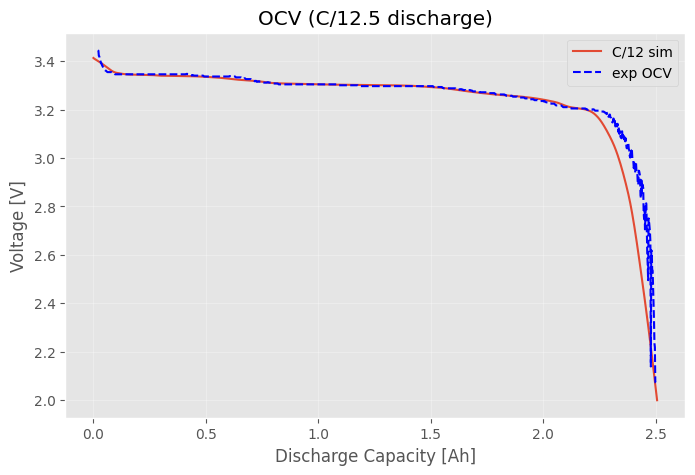

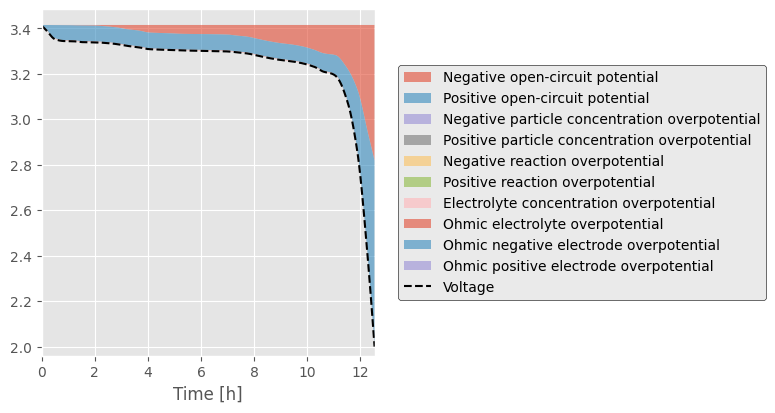

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [173]:
sol_ocv = run_experiment(
    ("Discharge at C/12.5 until 2 V",),
    label="C/12.5 OCV"
)

# Compare with experimental OCV
fig, ax = plt.subplots(figsize=(8, 5))
plot_VvsQ(sol_ocv, 'C/12 sim', ax)
try:
    df_exp = pd.read_excel('A123_data.xlsx', sheet_name='ocv')
    ax.plot(df_exp['Q'], df_exp['V'], '--', color='blue', label='exp OCV')
    ax.legend()
except FileNotFoundError:
    pass
ax.set_title('OCV (C/12.5 discharge)')
plt.show()

sol_ocv.plot_voltage_components(split_by_electrode=True)

## 7. Multi-rate discharge (from fully charged state)

[0.25C discharge] Vmax=3.4082V, Q_dis=2.5048Ah
[0.5C discharge] Vmax=3.4010V, Q_dis=2.5032Ah
[1C discharge] Vmax=3.3867V, Q_dis=2.5002Ah
[2C discharge] Vmax=3.3582V, Q_dis=2.4949Ah
[4C discharge] Vmax=3.3018V, Q_dis=2.4859Ah
[8C discharge] Vmax=3.1922V, Q_dis=2.4720Ah
[10C discharge] Vmax=3.1391V, Q_dis=2.4662Ah


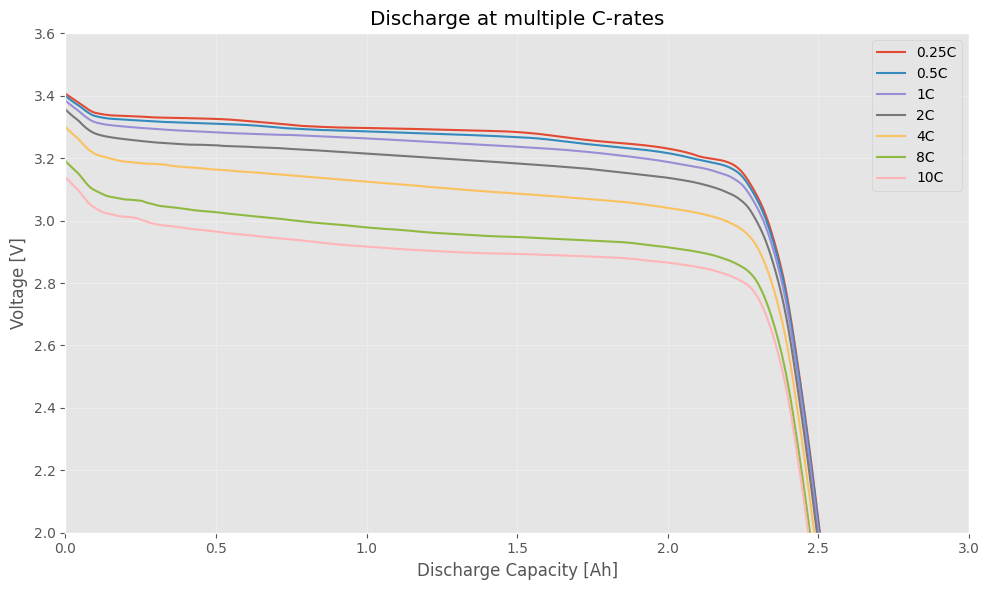

In [174]:
c_rates = [1/4, 1/2, 1, 2, 4, 8, 10]
discharge_results = {}

for cr in c_rates:
    try:
        sol = run_experiment(
            (f"Discharge at {cr}C until 2 V",),
            label=f"{cr}C discharge"
        )
        discharge_results[cr] = sol
    except Exception as e:
        print(f"  {cr}C FAILED: {e}")

fig, ax = plt.subplots(figsize=(10, 6))
for cr, sol in discharge_results.items():
    plot_VvsQ(sol, f'{cr}C', ax)
ax.set_ylim([2, 3.6]); ax.set_xlim([0, 3])
ax.set_title('Discharge at multiple C-rates')
plt.tight_layout(); plt.show()

## 8. Charge/discharge cycles (starting from C/12 discharged state)
Each charge starts from `sol_ocv` (fully discharged at C/12).

[1C cycle] Vmax=3.6000V, Q_dis=0.0778Ah


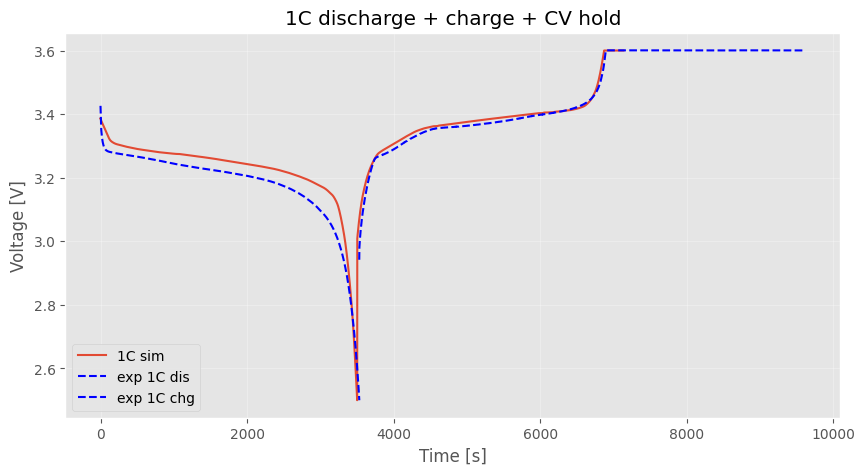

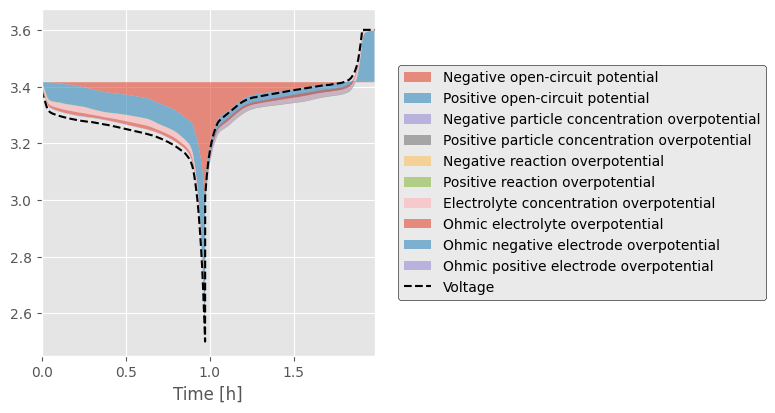

Discharge: 0.078 Ah | Charge: 4.708 Ah | CE: 6048.6%


In [175]:
# ── 1C: discharge + charge + CV hold ──
sol_1C = run_experiment(
    ("Discharge at 1C until 2.5 V", "Charge at 1C until 3.6 V", "Hold at 3.6 V until 10 mA"),
    label="1C cycle"
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_Vvst(sol_1C, '1C sim', ax)
try:
    df_1D = pd.read_excel('A123_data.xlsx', sheet_name='1D')
    df_1C = pd.read_excel('A123_data.xlsx', sheet_name='1C')
    ax.plot(df_1D['t'], df_1D['V'], '--', color='blue', label='exp 1C dis')
    ax.plot(df_1C['t']+3530, df_1C['V'], '--', color='blue', label='exp 1C chg')
    ax.legend()
except FileNotFoundError:
    pass
ax.set_title('1C discharge + charge + CV hold')
plt.show()
sol_1C.plot_voltage_components(split_by_electrode=True)

Q_dis = sol_1C["Discharge capacity [A.h]"].entries[-1]
Q_chg = sol_1C["Throughput capacity [A.h]"].entries[-1] - Q_dis
print(f"Discharge: {Q_dis:.3f} Ah | Charge: {Q_chg:.3f} Ah | CE: {Q_chg/Q_dis*100:.1f}%")

[2C cycle] Vmax=3.6000V, Q_dis=0.0778Ah


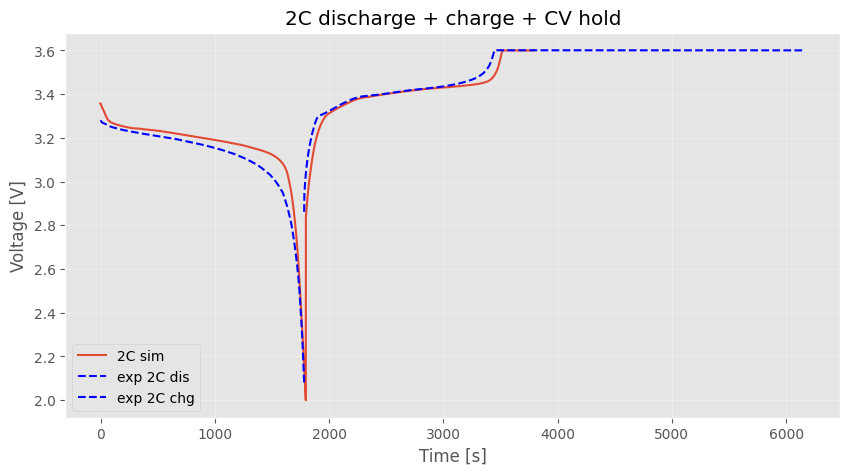

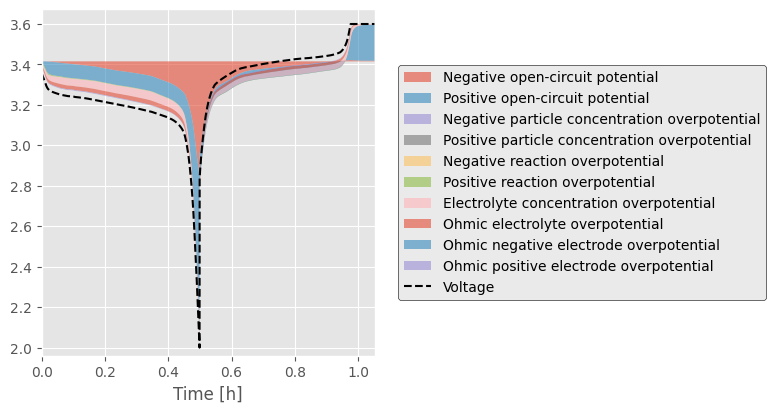

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [176]:
# ── 2C: discharge + charge + CV hold ──
sol_2C = run_experiment(
    ("Discharge at 2C until 2 V", "Charge at 2C until 3.6 V", "Hold at 3.6 V until 10 mA"),
    label="2C cycle"
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_Vvst(sol_2C, '2C sim', ax)
try:
    df_2D = pd.read_excel('A123_data.xlsx', sheet_name='2D')
    df_2C = pd.read_excel('A123_data.xlsx', sheet_name='2C')
    ax.plot(df_2D['t'], df_2D['V'], '--', color='blue', label='exp 2C dis')
    ax.plot(df_2C['t']+1782, df_2C['V'], '--', color='blue', label='exp 2C chg')
    ax.legend()
except FileNotFoundError:
    pass
ax.set_title('2C discharge + charge + CV hold')
plt.show()
sol_2C.plot_voltage_components(split_by_electrode=True)

## 9. Fast charge from discharged state
Charge at 3C and 4C starting from the end of 2C discharge.

[3C charge] Vmax=3.6000V, Q_dis=0.0718Ah


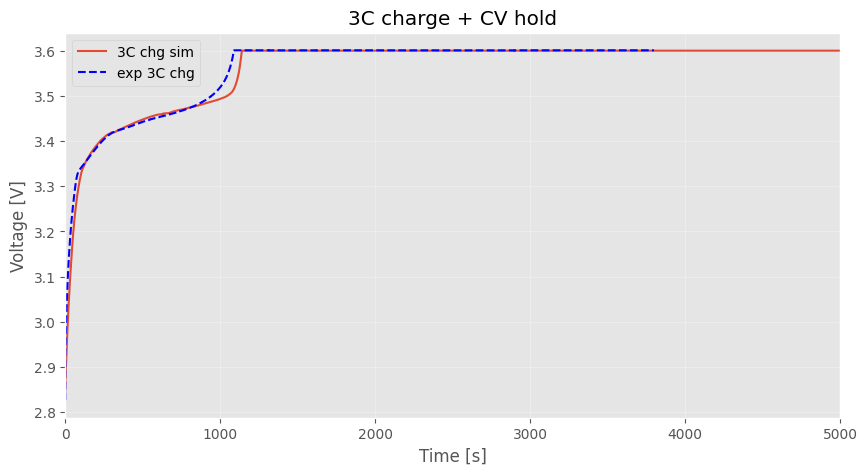

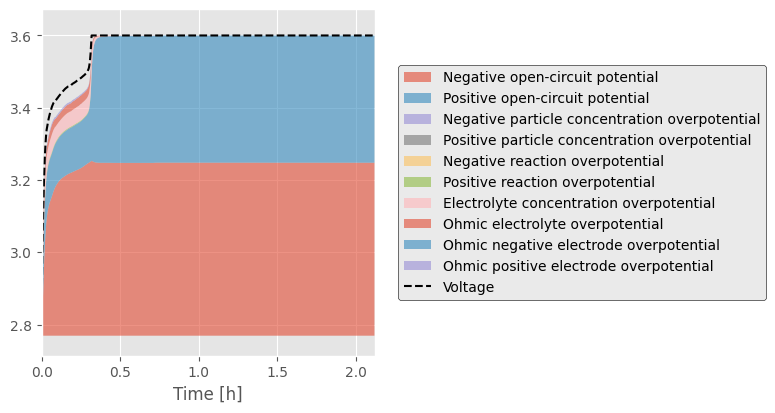

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [165]:
# ── 3C charge (from end of 2C cycle) ──
sol_3C_chg = run_experiment(
    ("Charge at 3C until 3.6 V", "Hold at 3.6 V until 2.5 mA"),
    init_sol=sol_ocv,
    label="3C charge"
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_Vvst(sol_3C_chg, '3C chg sim', ax)
try:
    df_3C = pd.read_excel('A123_data.xlsx', sheet_name='3C')
    ax.plot(df_3C['t'], df_3C['V'], '--', color='blue', label='exp 3C chg')
    ax.legend()
except FileNotFoundError:
    pass
ax.set_xlim([0, 5000]); ax.set_title('3C charge + CV hold')
plt.show()
sol_3C_chg.plot_voltage_components(split_by_electrode=True)

[4C charge] Vmax=3.6000V, Q_dis=0.0533Ah


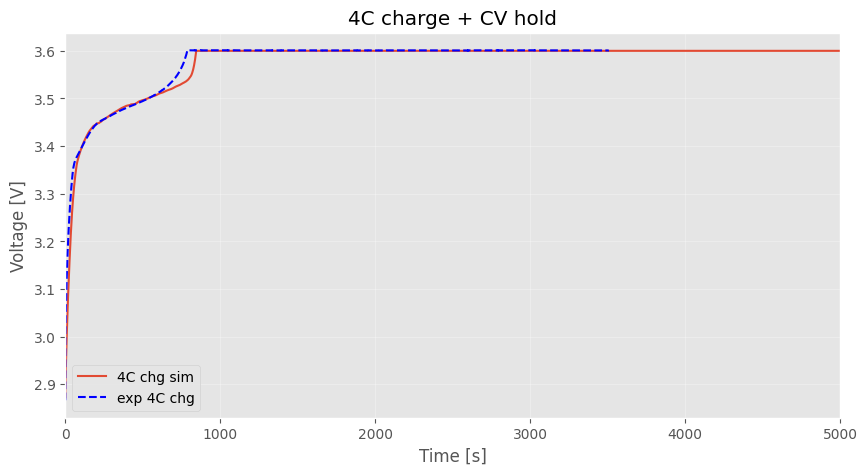

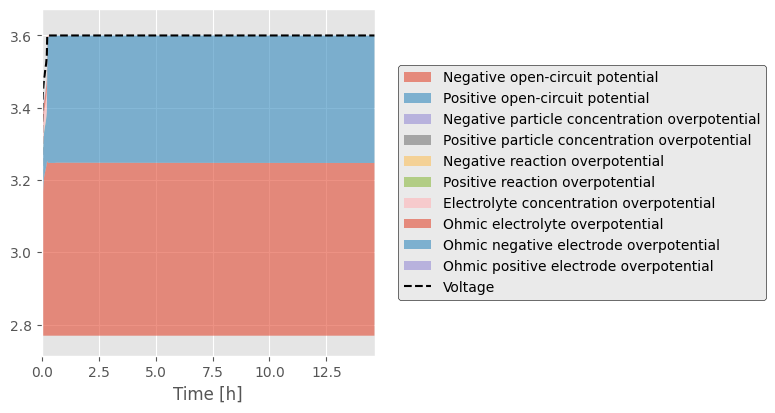

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [166]:
# ── 4C charge (from end of 3C charge) ──
sol_4C_chg = run_experiment(
    ("Charge at 4C until 3.6 V", "Hold at 3.6 V until 1 mA"),
    init_sol=sol_ocv,
    label="4C charge"
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_Vvst(sol_4C_chg, '4C chg sim', ax)
try:
    df_4C = pd.read_excel('A123_data.xlsx', sheet_name='4C')
    ax.plot(df_4C['t'], df_4C['V'], '--', color='blue', label='exp 4C chg')
    ax.legend()
except FileNotFoundError:
    pass
ax.set_xlim([0, 5000]); ax.set_title('4C charge + CV hold')
plt.show()
sol_4C_chg.plot_voltage_components(split_by_electrode=True)

# HPPC

In [181]:
experiment = pb.Experiment(
    [   "Discharge at C/20 until 3.3 V",
        "Hold at 3.3 V until 25 mA"],
)
sim_cccv = pb.Simulation(model, experiment, parameter_values=param)
sol_cccv = sim_cccv.solve()
print(sol_cccv["Voltage [V]"].entries[0:])

[3.41388071 3.41387615 3.41387022 3.4138582  3.4138382  3.41382082
 3.4137911  3.41376431 3.41373943 3.41369407 3.41365158 3.41357329
 3.41343091 3.41329763 3.41305324 3.4128242  3.41260639 3.41218903
 3.41179398 3.41141353 3.41104117 3.41067322 3.40994366 3.40921559
 3.40848721 3.40775898 3.40630288 3.40590171 3.40546775 3.40507293
 3.40471255 3.40437286 3.40403358 3.40370139 3.4030384  3.40171708
 3.4010496  3.40084867 3.40064389 3.4004371  3.40022959 3.40002364
 3.39961497 3.39921121 3.3988136  3.39841826 3.39802677 3.39724698
 3.39646916 3.39607634 3.3958758  3.3956723  3.39546675 3.39526092
 3.39505498 3.39464151 3.39421856 3.39380358 3.39338372 3.39297009
 3.39254351 3.39211752 3.39126445 3.39097054 3.39067125 3.39036719
 3.39011307 3.38985703 3.38959852 3.38933564 3.38880776 3.38828396
 3.3877614  3.38723333 3.38670338 3.38564935 3.38458075 3.38419398
 3.38380062 3.38349055 3.38317936 3.38286814 3.38224673 3.38162204
 3.38100156 3.38038119 3.37976333 3.3791457  3.37853052 3.3779

In [182]:
#####Drive cycle

drive_cycle = pd.read_excel("HPPC_data.xlsx").to_numpy()
time = drive_cycle[:, 0].astype(float)
current = drive_cycle[:, 1].astype(float)
voltage = drive_cycle[:,2].astype(float)

current_interpolant = pb.Interpolant(time, current, pb.t)
print(drive_cycle[:, 0])

param.update(
    {
        "Current function [A]" : current_interpolant,
    }
)

drive_cycle_model = model.set_initial_conditions_from(sol_cccv, inplace=True)
drive_cycle_model.events_tol = 1e-6

# Step 6: Solve
sim = pb.Simulation(drive_cycle_model, parameter_values=param)  # let defaults handle it
solution = sim.solve(t_eval=time, solver=pb.CasadiSolver(mode="safe"))

# Step 7: Plot
sim.plot(["Voltage [V]"])

[0.00000000e+00 9.09972936e-02 1.92002580e-01 ... 9.06920080e+04
 9.06920210e+04 9.07020340e+04]


interactive(children=(FloatSlider(value=0.0, description='t', max=25.19500944390892, step=0.25195009443908917)…

In [183]:
voltage_sim = solution['Terminal voltage [V]'].entries[0:]
time_sim = solution['Time [s]'].entries[0:]
print(voltage_sim)

[3.31556626 3.31556478 3.31556515 ... 3.31462564 3.31462564 3.31462649]


In [184]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=time, y=voltage, 
                         mode='lines', name='exp', line=dict(color='red')))

fig.add_trace(go.Scatter(x=time_sim, y=voltage_sim, 
                         mode='lines', name='sim', line=dict(color='blue')))

fig.update_layout(
    width=1400, height=800,
    title='Experimental vs Simulated Voltage',
    xaxis_title='Time (s)',
    yaxis_title='Voltage (V)',
    yaxis=dict(range=[0, 4]),
    legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=time_sim, y=voltage_sim-voltage, 
                         mode='lines', name='sim', line=dict(color='red')))


fig.update_layout(
    width=1400, height=800,
    title='Experimental vs Simulated Voltage',
    xaxis_title='Time (s)',
    yaxis_title='Voltage (V)',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)

fig.show()

In [185]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Interpolate model voltage onto the experimental SOC points
model_voltage_at_exp_SOC = np.interp(time, time_sim, voltage_sim)

# Compute RMSE between experiment and model
rmse = np.sqrt(mean_squared_error(voltage, model_voltage_at_exp_SOC))
print(f"RMSE: {1000*rmse:.4f} mV")

RMSE: 101.4177 mV
